In [ ]:
# Load packages
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

import plotly.graph_objects as go
from wordcloud import WordCloud
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [3]:
# Load in our dataset
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

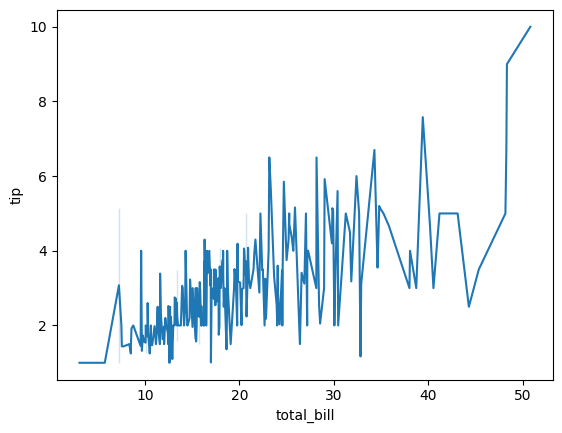

In [ ]:
# Make a lineplot with seaborn
sns.lineplot(data = tips,
             x = "total_bill", 
             y = "tip")

<Axes: xlabel='total_bill', ylabel='tip'>

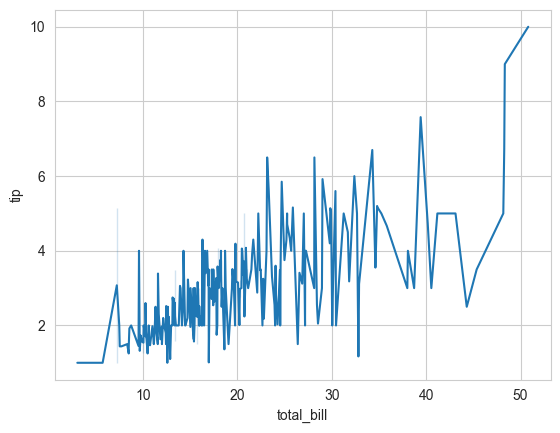

In [8]:
# Change the style of the plot
sns.set_style("whitegrid")

sns.lineplot(data = tips,
             x = "total_bill", 
             y = "tip")

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

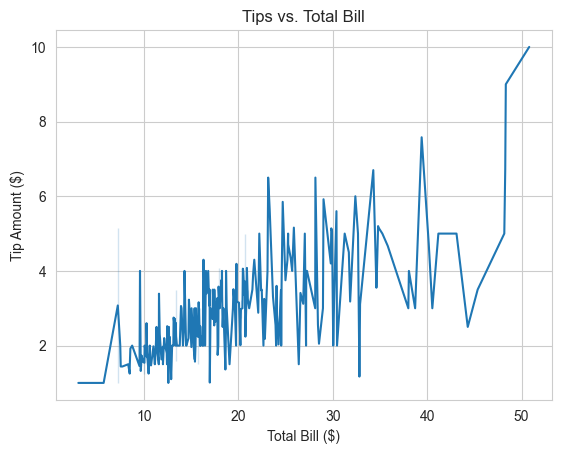

In [9]:
# Add title and axis labels
tipgraph = sns.lineplot(data = tips,
             x = "total_bill", 
             y = "tip")

tipgraph.set(title = "Tips vs. Total Bill", 
             xlabel = "Total Bill ($)", 
             ylabel = "Tip Amount ($)")

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

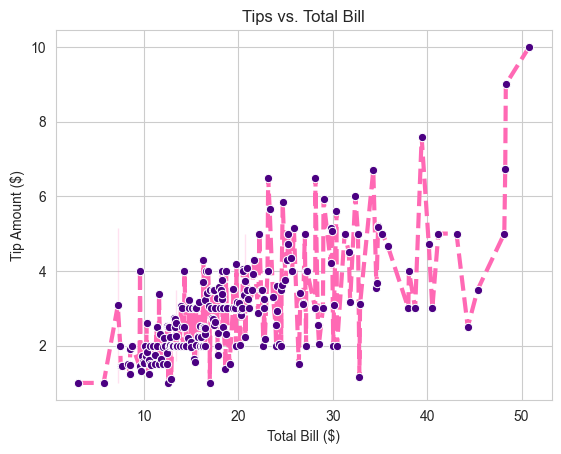

In [11]:
# Modify aesthetics of the graph
tipgraph = sns.lineplot(data = tips,
             x = "total_bill", 
             y = "tip", 
             color = "hotpink", 
             linestyle = "--", 
             linewidth = 3, 
             marker = "o", 
             markerfacecolor = "indigo")

tipgraph.set(title = "Tips vs. Total Bill", 
             xlabel = "Total Bill ($)", 
             ylabel = "Tip Amount ($)")

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

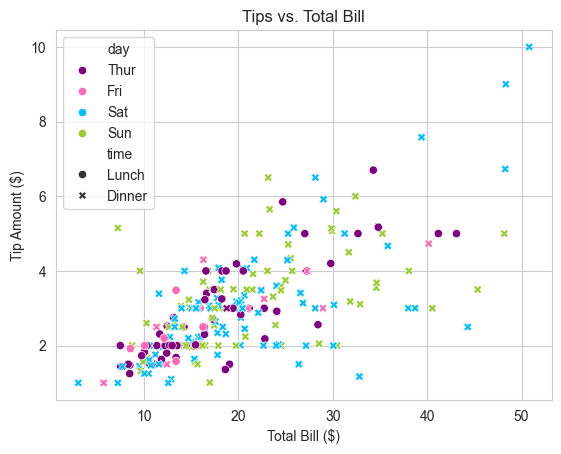

In [ ]:
# Use seaborn to add multiple variables to the same graph
tipgraph = sns.scatterplot(data = tips,
             x = "total_bill", 
             y = "tip", 
             style = "time", # Shape points based on time column
             hue = "day", # Color points based on day column
             palette = ["purple", "hotpink", "deepskyblue", "yellowgreen"])

tipgraph.set(title = "Tips vs. Total Bill", 
             xlabel = "Total Bill ($)", 
             ylabel = "Tip Amount ($)")

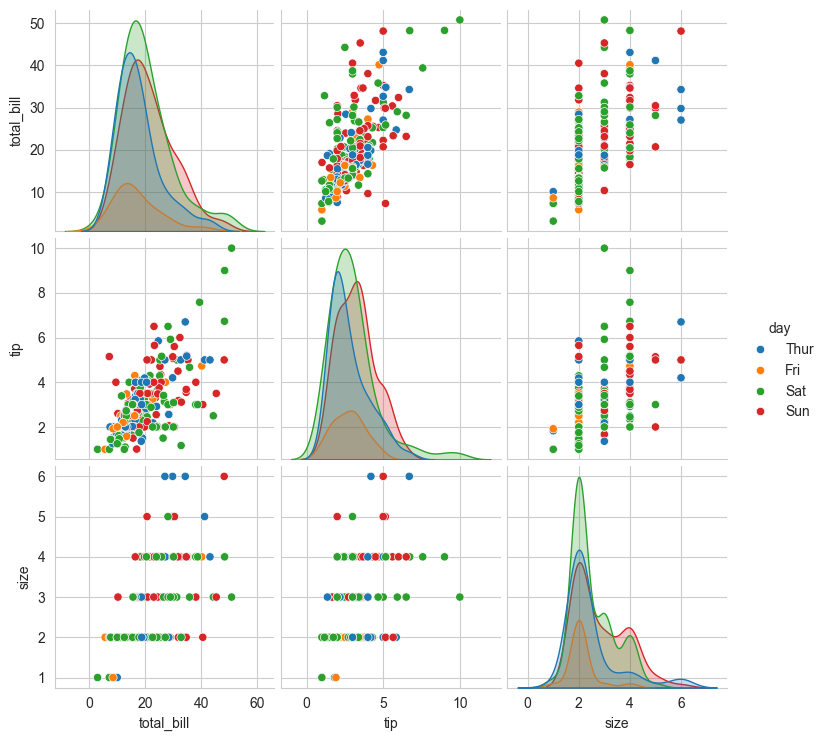

In [16]:
# Make a pairplot to compare all pairs of variables, 
# separated by day
sns.pairplot(data = tips,
             hue = "day")

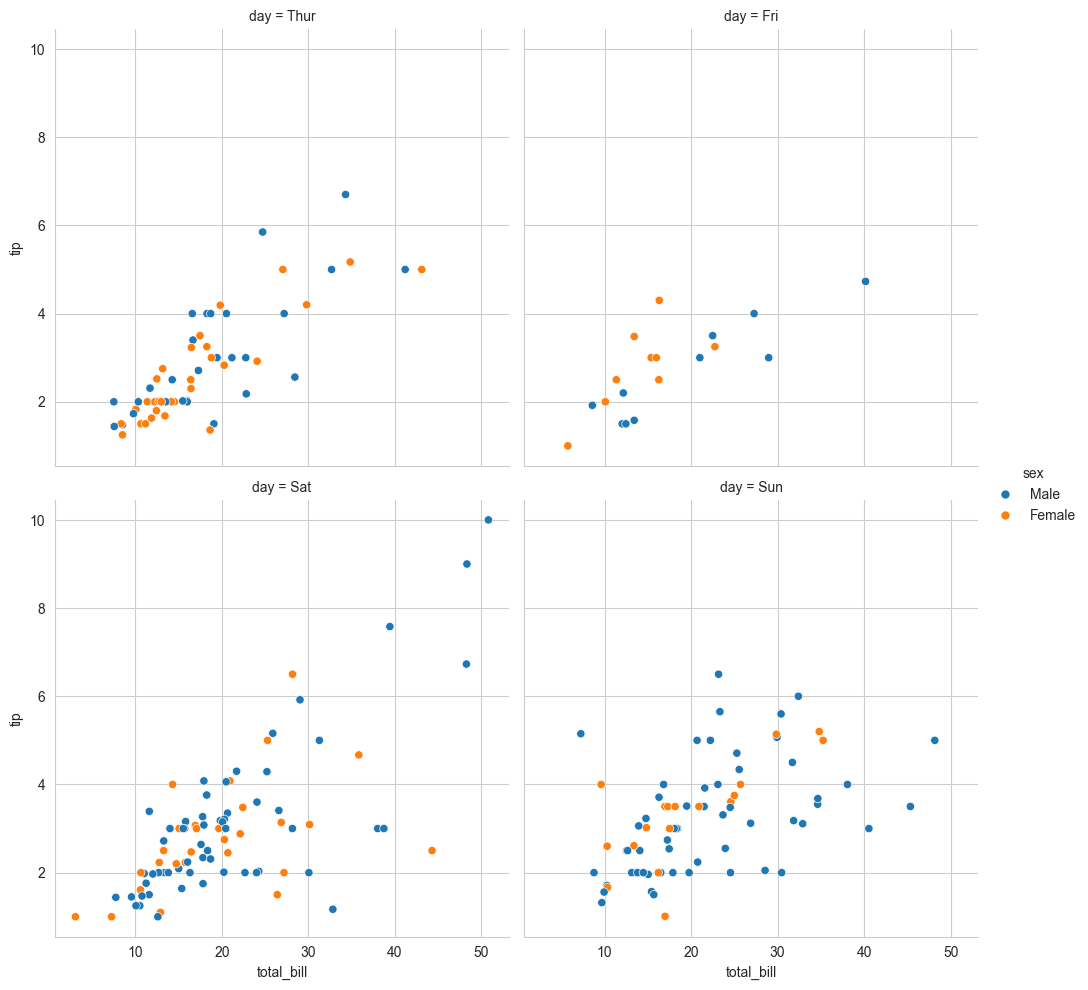

In [21]:
# Make a relplot

# Plot total bill against tip, separately for each day,
# coloring data points by sex
daysplot = sns.relplot(data = tips, 
                      x = "total_bill",
                      y = "tip",
                      hue = "sex",
                      col = "day",
                      kind = "scatter",
                      col_wrap = 2)

In [22]:
# Set up our data
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [23]:
# Make a bar plot with plotly
graph = go.Figure()

graph.add_trace(go.Bar(x = x1, y = y1))

In [25]:
# Add titles
graph.update_layout(title = "Pirate Scores",
                    xaxis_title = "Pirates",
                    yaxis_title = "Score")

In [26]:
# Save graph as HTML file
graph.write_html("./pirategraph.html")

In [28]:
# Customizing plotly graphs
graph = go.Figure()

graph.add_trace(go.Scatter(x = x1, y = y1,
                           mode = "markers", 
                           marker = dict(size = 15,
                                         color = "hotpink",
                                         opacity = 1,
                                         line = dict(width = 5,
                                                     color = "purple"))))

graph.update_layout(title = "Interactive Pirate Plot",
                    xaxis_title = "Pirates",
                    yaxis_title = "Scores",
                    width = 500,
                    height = 500)

In [29]:
# Load in data for making a word cloud
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
on_bad_lines='skip')
print(df)

                                                 quote  \
0                      Do, or do not. There is no try.   
1    Listen to them. Children of the night. What mu...   
2                              It's alive! It's alive!   
3    Oh, no, it wasn't the airplanes. It was Beauty...   
4    Magic Mirror on the wall, who is the fairest o...   
..                                                 ...   
727  I didn't know if you were lost. Stick with me....   
728  This guy's awesome! He's holding his own while...   
729     Murder is murder, it don’t matter who you are.   
730  You know what a lion is? A lion is a strong an...   
731  That was the best acting i've ever seen in my ...   

                                              movie   type  year  
0    Star Wars: Episode V - The Empire Strikes Back  movie  1890  
1                                           Dracula  movie  1931  
2                                      Frankenstein  movie  1931  
3                                  

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

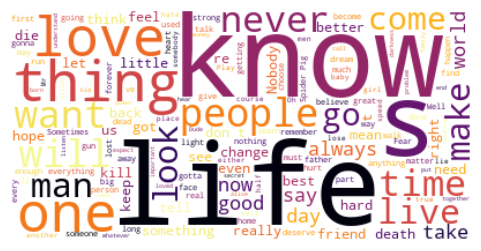

In [39]:
# Make a word cloud

# Join all of our quotes together
text = " ".join(each for each in df.quote)

# Make the word cloud
wordcloud = WordCloud(background_color = "white",
                      colormap = "inferno").generate(text)

# Put the word cloud into a figure
fix, ax = plt.subplots(figsize = (7, 3))
ax.imshow(wordcloud,
          interpolation = "bilinear")
ax.axis("off")

c:\Users\Mexla\Desktop\visualization\visualization-env\Lib\site-packages\matplotlib_venn\_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



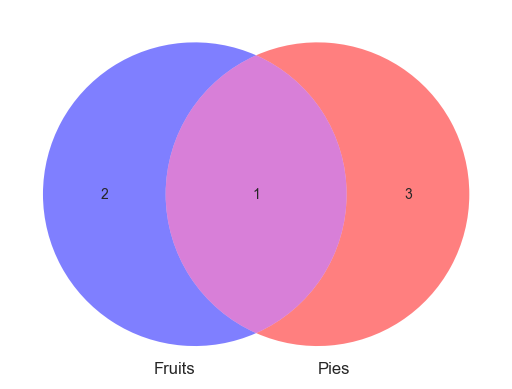

In [41]:
# Make venn diagrams
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

diagram = venn2_unweighted([A, B],
                           set_labels = ("Fruits", "Pies"),
                           set_colors = ("blue", "red"),
                           alpha = 0.5)

plt.show()

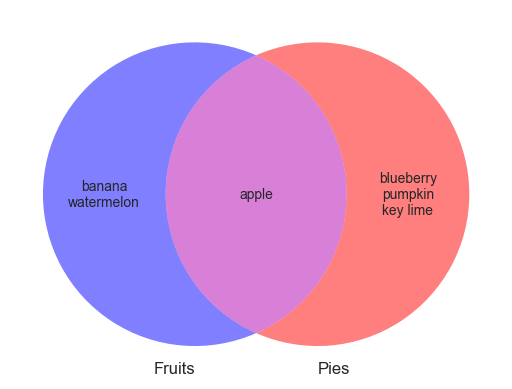

In [ ]:
# Modify our Venn diagram
diagram = venn2_unweighted([A, B],
                           set_labels = ("Fruits", "Pies"),
                           set_colors = ("blue", "red"),
                           alpha = 0.5)

diagram.get_label_by_id("10").set_text("\n".join(A - B)) # in A but not B

diagram.get_label_by_id("11").set_text("\n".join(A & B)) # in A and B

diagram.get_label_by_id("01").set_text("\n".join(B - A)) # in B but not A

plt.show()